
## **Assignment 1**: Linear Regression (Univariate and Multivariate)

### Problem Statement

| Motive | Dataset |
|--------|---------| 
|The price of a used car|Used_Car_dataset.csv|
|The price of a House|Housing.csv|
|Fuel Consumption|Fuel_Consumption_2000-2022.csv|

Consider both univariate and multivariate cases for these problems.\
Elaborate gradient descent algorithm and hyper-parameter tuning for the best result with predefined convergent criteria.\
Display the model  ( also called the hypothesis function) and find the accuracy of the linear regression in predicting the correct price.

#### Data Loading

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# loading datasets
car_df = pd.read_csv('Datasets/Used_Car_dataset.csv')
house_df = pd.read_csv('Datasets/Housing.csv')
fuel_df = pd.read_csv('Datasets/Fuel_Consumption_2000-2022.csv')

In [3]:
# Custom Linear Regression using Gradient Descent

def gradient_descent(X, y, theta, rate, iterations):
    
    m = len(y) # number of training samples
    cost_history = np.zeros(iterations)
    tolerance = 1e-6
    prev_cost = float('inf') #infinity initialization

    for i in range(iterations):

        #theta = theta - (rate/m) * X.T.dot(X.dot(theta) - Y)

        predictions = X @ theta
        errors = predictions - y
        gradient = (X.T @ errors) / m
        theta = theta - rate * gradient

        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history[i] = cost

        # Debugging every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost_history[i]}")

        # Cost Difference Threshold
        if abs(prev_cost - cost) < tolerance:
            print(f"Converged at iteration {i}, Cost: {cost}")
            break

        prev_cost = cost

    return theta, cost_history

#### Used_Car_Dataset

##### Exploratory Data Analysis (EDA)

In [4]:
car_df.head()

,Year,Mileage_km,Engine_Size_cc,Num_Owners,Fuel_Efficiency_kmpl,Price_INR
0,2014,127989,3062,3,16.249345,1.636551e+06
1,2017,281393,4029,2,17.237899,2.206040e+06
2,2001,249255,2916,3,13.180936,2.615662e+05
3,2009,115361,1192,4,11.090744,1.660000e+05
4,2022,291744,1908,4,9.460477,1.660000e+05


In [5]:
print(f"The dataset has {car_df.shape[0]} rows and {car_df.shape[1]} columns")

The dataset has 1000 rows and 6 columns


In [6]:
#Dataset info and data types
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  1000 non-null   int64  
 1   Mileage_km            1000 non-null   int64  
 2   Engine_Size_cc        1000 non-null   int64  
 3   Num_Owners            1000 non-null   int64  
 4   Fuel_Efficiency_kmpl  1000 non-null   float64
 5   Price_INR             1000 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


In [7]:
car_df.describe()

,Year,Mileage_km,Engine_Size_cc,Num_Owners,Fuel_Efficiency_kmpl,Price_INR
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2012.075000,154384.549000,2889.022000,2.467000,16.181838,1.365888e+06
std,7.017308,84670.754092,1186.074548,1.120789,4.815273,9.697702e+05
min,2000.000000,5074.000000,802.000000,1.000000,8.004130,1.660000e+05
25%,2006.000000,81464.750000,1878.250000,1.000000,12.005658,4.319605e+05
50%,2012.000000,155842.500000,2861.000000,2.000000,16.010321,1.274551e+06
75%,2018.000000,230007.750000,3955.000000,3.000000,20.129858,2.120546e+06
max,2023.000000,299478.000000,4998.000000,4.000000,24.981380,4.162013e+06


In [8]:
# Missing value check
car_df.isnull().sum()

Year                    0
Mileage_km              0
Engine_Size_cc          0
Num_Owners              0
Fuel_Efficiency_kmpl    0
Price_INR               0
dtype: int64

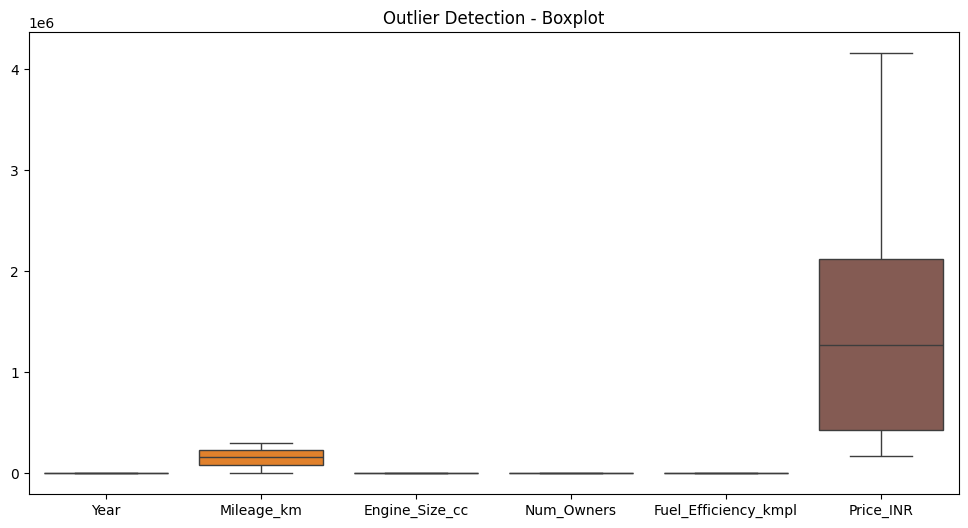

In [9]:
# Outlier detection
plt.figure(figsize=(12,6))
sns.boxplot(data=car_df)
plt.title("Outlier Detection - Boxplot")
plt.show()

In [10]:
q1 = car_df['Price_INR'].quantile(0.25)
q3 = car_df['Price_INR'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = car_df[(car_df['Price_INR'] < lower_bound) | (car_df['Price_INR'] > upper_bound)]
print(f"Outliers in Price_INR: {len(outliers)}")

Outliers in Price_INR: 0


Using the IQR method and the boxplot visualization, we found no statistical outliers in `Price_INR`

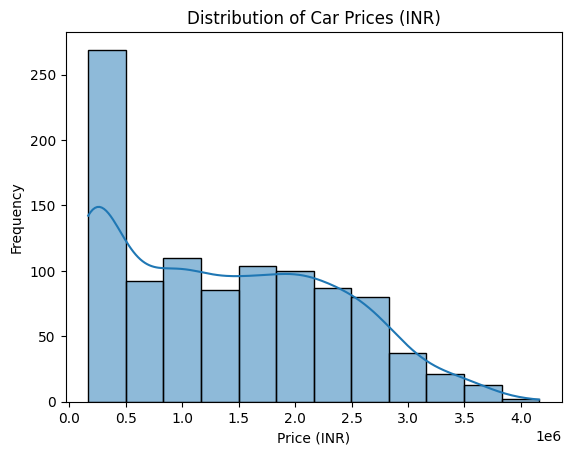

In [11]:
# Distribution of target variable

sns.histplot(car_df['Price_INR'], kde=True)
plt.title("Distribution of Car Prices (INR)")
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.show()

The target variable distribution is `right-skewed`:
- Most cars are priced in the lower range.
- Small number of vehicles extend the price range.

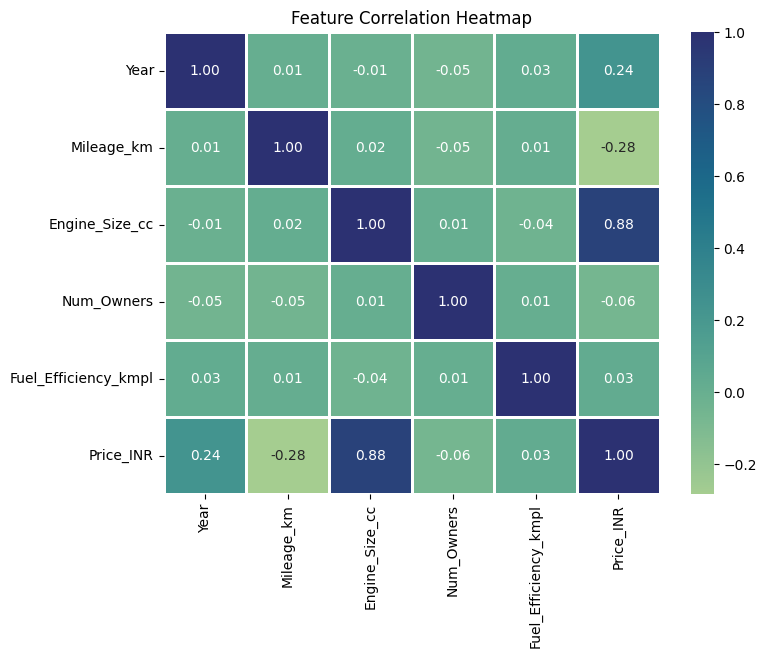

In [12]:
# Feature Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(car_df.corr(), annot=True, cmap='crest', fmt='.2f', linewidths=2)
plt.title("Feature Correlation Heatmap")
plt.show()

Key observations:
- `Engine_Size_cc` has a **very strong positive correlation** with `Price_INR` (r = 0.88), making it the best candidate for **univariate linear regression**.
- `Mileage_km` shows a **moderate negative correlation**.

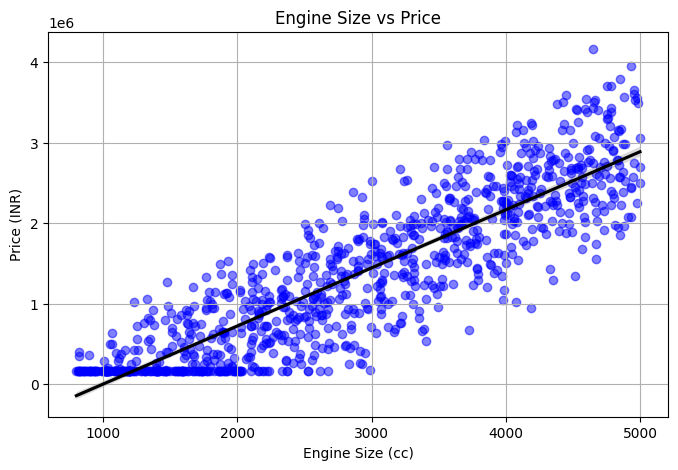

In [13]:
# Scatterplot: Engine_Size_cc vs Price_INR

plt.figure(figsize=(8, 5))
sns.regplot(
    x=car_df["Engine_Size_cc"],
    y=car_df["Price_INR"],
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

The scatterplot confirms a **strong linear relationship** between engine size and car prices.

> Based on this, `Engine_Size_cc` is selected for univariate regression.

##### Univariate Linear Regression

In [14]:
#Splitting of data

X_uni = car_df[['Engine_Size_cc']].values
y = car_df[['Price_INR']].values

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_uni, y, test_size=0.2, random_state=42)

In [16]:
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")

Training set shape: X=(800, 1), y=(800, 1)
Testing set shape: X=(200, 1), y=(200, 1)


In [17]:
#Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
baseline_model = LinearRegression()

In [19]:
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [20]:
y_pred = baseline_model.predict(X_test_scaled)

In [21]:
#Baseline model evaluation

baseline_mae = mean_absolute_error(y_test, y_pred)
baseline_mse = mean_squared_error(y_test, y_pred)
baseline_r2 = r2_score(y_test, y_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline MSE: {baseline_mse:.2f}")
print(f"Baseline R² Score: {baseline_r2:.4f}")

Baseline MAE: 344733.62
Baseline MSE: 208541608803.37
Baseline R² Score: 0.7733


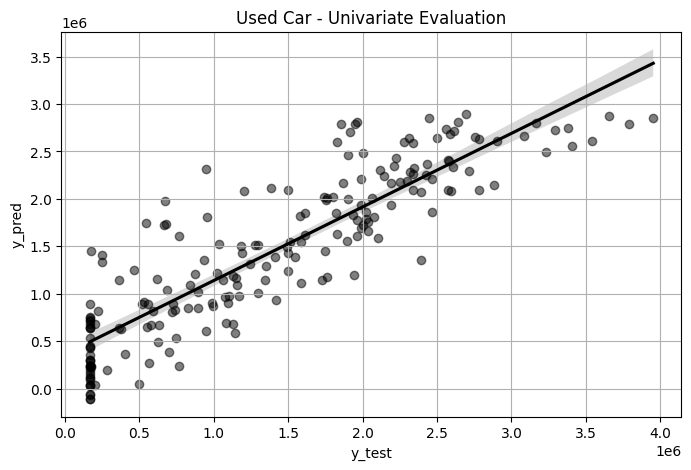

In [22]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'color': 'black', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Used Car - Univariate Evaluation")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.show()

These results provide a benchmark for evaluating our custom gradient descent implementation next.

In [23]:
# Adding bias (intercept) term

X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [24]:
# Reshaping y into column vector

y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

In [25]:
# Initialize theta with zeros
theta_init = np.zeros((X_train_bias.shape[1], 1))

In [26]:
# Running gradient descent

learning_rate = 0.01
iterations = 1000

theta_final, cost_history = gradient_descent(X_train_bias, y_train_col, theta_init, learning_rate, iterations)

Iteration 0, Cost: 1398264604158.8318
Iteration 100, Cost: 276857368065.2708
Iteration 200, Cost: 126611591190.08978
Iteration 300, Cost: 106481710855.57117
Iteration 400, Cost: 103784716033.42268
Iteration 500, Cost: 103423373544.05763
Iteration 600, Cost: 103374960994.82011
Iteration 700, Cost: 103368474697.21423
Iteration 800, Cost: 103367605665.16997
Iteration 900, Cost: 103367489232.53926


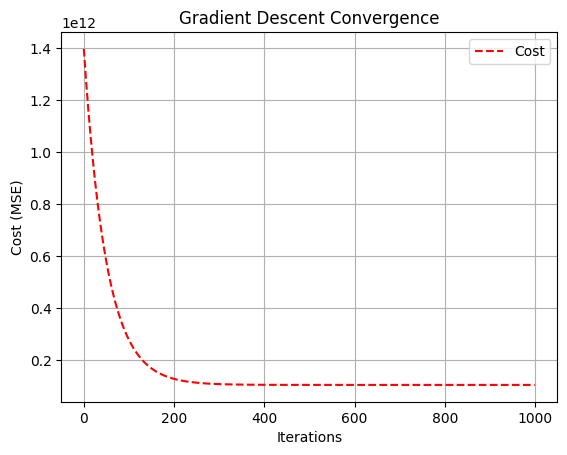

In [27]:
# Gradient Descent convergence

plt.plot(range(len(cost_history)), cost_history, color='red', linestyle='dashed', label='Cost')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Predictions on test set
y_pred_gd = X_test_bias @ theta_final

In [29]:
# Gradient descent evaluattion
mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Gradient Descent MAE: {mae_gd:.2f}")
print(f"Gradient Descent MSE: {mse_gd:.2f}")
print(f"Gradient Descent R² Score: {r2_gd:.4f}")

Gradient Descent MAE: 344732.16
Gradient Descent MSE: 208535193319.96
Gradient Descent R² Score: 0.7733


This confirms that our implementation is mathematically sound and practically accurate.

##### Multivariate Linear Regression

In [30]:
# Feature Selection

X = car_df.drop(columns=['Price_INR']).values
y = car_df[['Price_INR']].values

In [31]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# Baseline Model

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [34]:
#Predict
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [35]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_baseline)
mse = mean_squared_error(y_test, y_pred_baseline)
r2 = r2_score(y_test, y_pred_baseline)

print(f"Sklearn MAE: {mae:.2f}")
print(f"Sklearn MSE: {mse:.2f}")
print(f"Sklearn R² Score: {r2:.4f}")

Sklearn MAE: 185863.56
Sklearn MSE: 59440643803.08
Sklearn R² Score: 0.9354


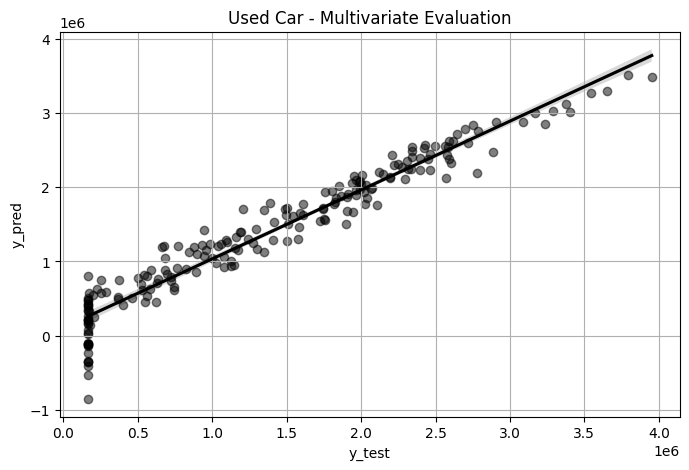

In [36]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=y_test,
    y=y_pred_baseline,
    scatter_kws={'color': 'black', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Used Car - Multivariate Evaluation")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.show()

This model serves as a benchmark to compare against our custom gradient descent implementation.

Applying **Gradient Descent**:

In [37]:
# Adding bias term
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [38]:
# Reshaping target
y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

In [39]:
theta_init = np.zeros((X_train_bias.shape[1], 1))

In [40]:
learning_rate = 0.01
iterations = 1000

theta_final, cost_history = gradient_descent(X_train_bias, y_train_col, theta_init, learning_rate, iterations)

Iteration 0, Cost: 1398264604158.8318
Iteration 100, Cost: 212951618477.31973
Iteration 200, Cost: 52059992190.463524
Iteration 300, Cost: 30188626076.92367
Iteration 400, Cost: 27211158838.904102
Iteration 500, Cost: 26805240956.78526
Iteration 600, Cost: 26749823695.34745
Iteration 700, Cost: 26742247232.11664
Iteration 800, Cost: 26741209932.63694
Iteration 900, Cost: 26741067712.284107


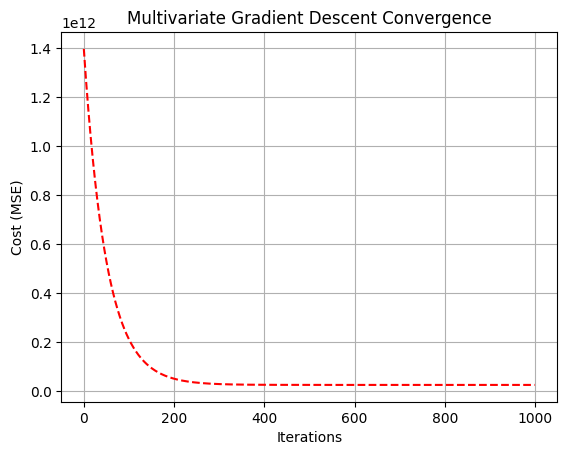

In [41]:
# Cost convergence plot

plt.plot(range(len(cost_history)), cost_history, linestyle='dashed', color='red')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Multivariate Gradient Descent Convergence")
plt.grid(True)
plt.show()

In [42]:
y_pred_gd = X_test_bias @ theta_final

In [43]:
mae_gd = mean_absolute_error(y_test_col, y_pred_gd)
mse_gd = mean_squared_error(y_test_col, y_pred_gd)
r2_gd = r2_score(y_test_col, y_pred_gd)

print(f"GD MAE: {mae_gd:.2f}")
print(f"GD MSE: {mse_gd:.2f}")
print(f"GD R² Score: {r2_gd:.4f}")

GD MAE: 185864.18
GD MSE: 59440742602.35
GD R² Score: 0.9354


The results closely match the Scikit-learn model, validating our gradient descent implementation for multivariate linear regression. 

#### Housing Dataset

##### Exploratory Data Analysis (EDA)

In [44]:
house_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [45]:
print(f"The dataset has {house_df.shape[0]} rows and {house_df.shape[1]} columns")

The dataset has 545 rows and 13 columns


In [46]:
#Dataset info and data types
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [47]:
house_df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [48]:
house_df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

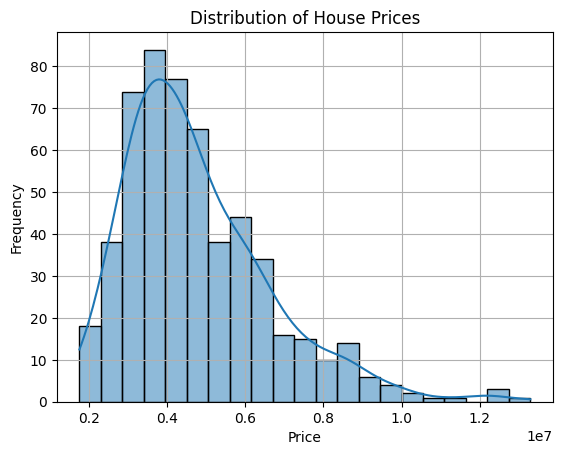

In [49]:
# Distribution of target variable

sns.histplot(house_df['price'], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

The target variable `price` shows a **right-skewed distribution**.

In [50]:
house_df['price'] = np.log1p(house_df['price'])

In [51]:
house_df['area'] = np.log1p(house_df['area']) 

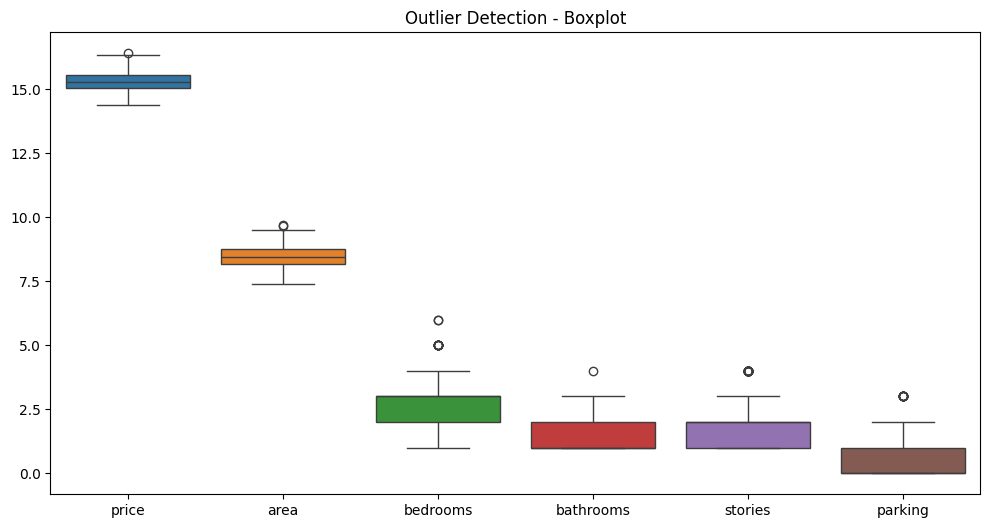

In [52]:
# Outlier detection
plt.figure(figsize=(12,6))
sns.boxplot(data=house_df)
plt.title("Outlier Detection - Boxplot")
plt.show()

In [53]:
q1 = house_df['price'].quantile(0.25)
q3 = house_df['price'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = house_df[(house_df['price'] < lower) | (house_df['price'] > upper)]
print(f"Outliers in price: {len(outliers)}")

Outliers in price: 1


In [54]:
# Removing outliers using inverse condition
house_df = house_df[~((house_df['price'] < lower) | (house_df['price'] > upper))]

In [55]:
for col in house_df.select_dtypes(include='object').columns:
    print(f"\n{house_df[col].value_counts()}\n")


mainroad
yes    467
no      77
Name: count, dtype: int64


guestroom
no     447
yes     97
Name: count, dtype: int64


basement
no     353
yes    191
Name: count, dtype: int64


hotwaterheating
no     519
yes     25
Name: count, dtype: int64


airconditioning
no     373
yes    171
Name: count, dtype: int64


prefarea
no     417
yes    127
Name: count, dtype: int64


furnishingstatus
semi-furnished    227
unfurnished       178
furnished         139
Name: count, dtype: int64



In [56]:
# Label encoding binary yes/no columns:
encoded_df = house_df.copy()

encoded_df = pd.get_dummies(encoded_df, 
                            columns=house_df.select_dtypes(include='object').columns, 
                            drop_first=True)

A temporary encoded copy (`encoded_df`) was created for correlation analysis. This preserves the original dataset for flexible preprocessing later when building regression models.

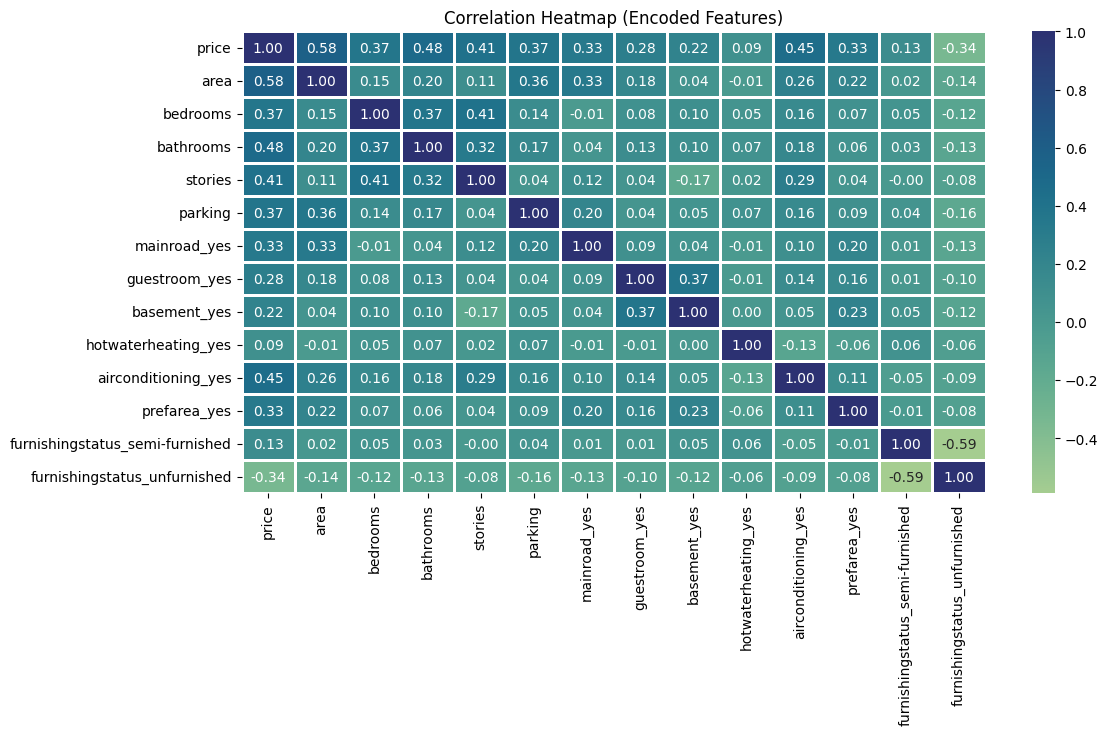

In [57]:
# Feature Correlation Heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(encoded_df.corr(), annot=True, cmap='crest', fmt='.2f', linewidths=2)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

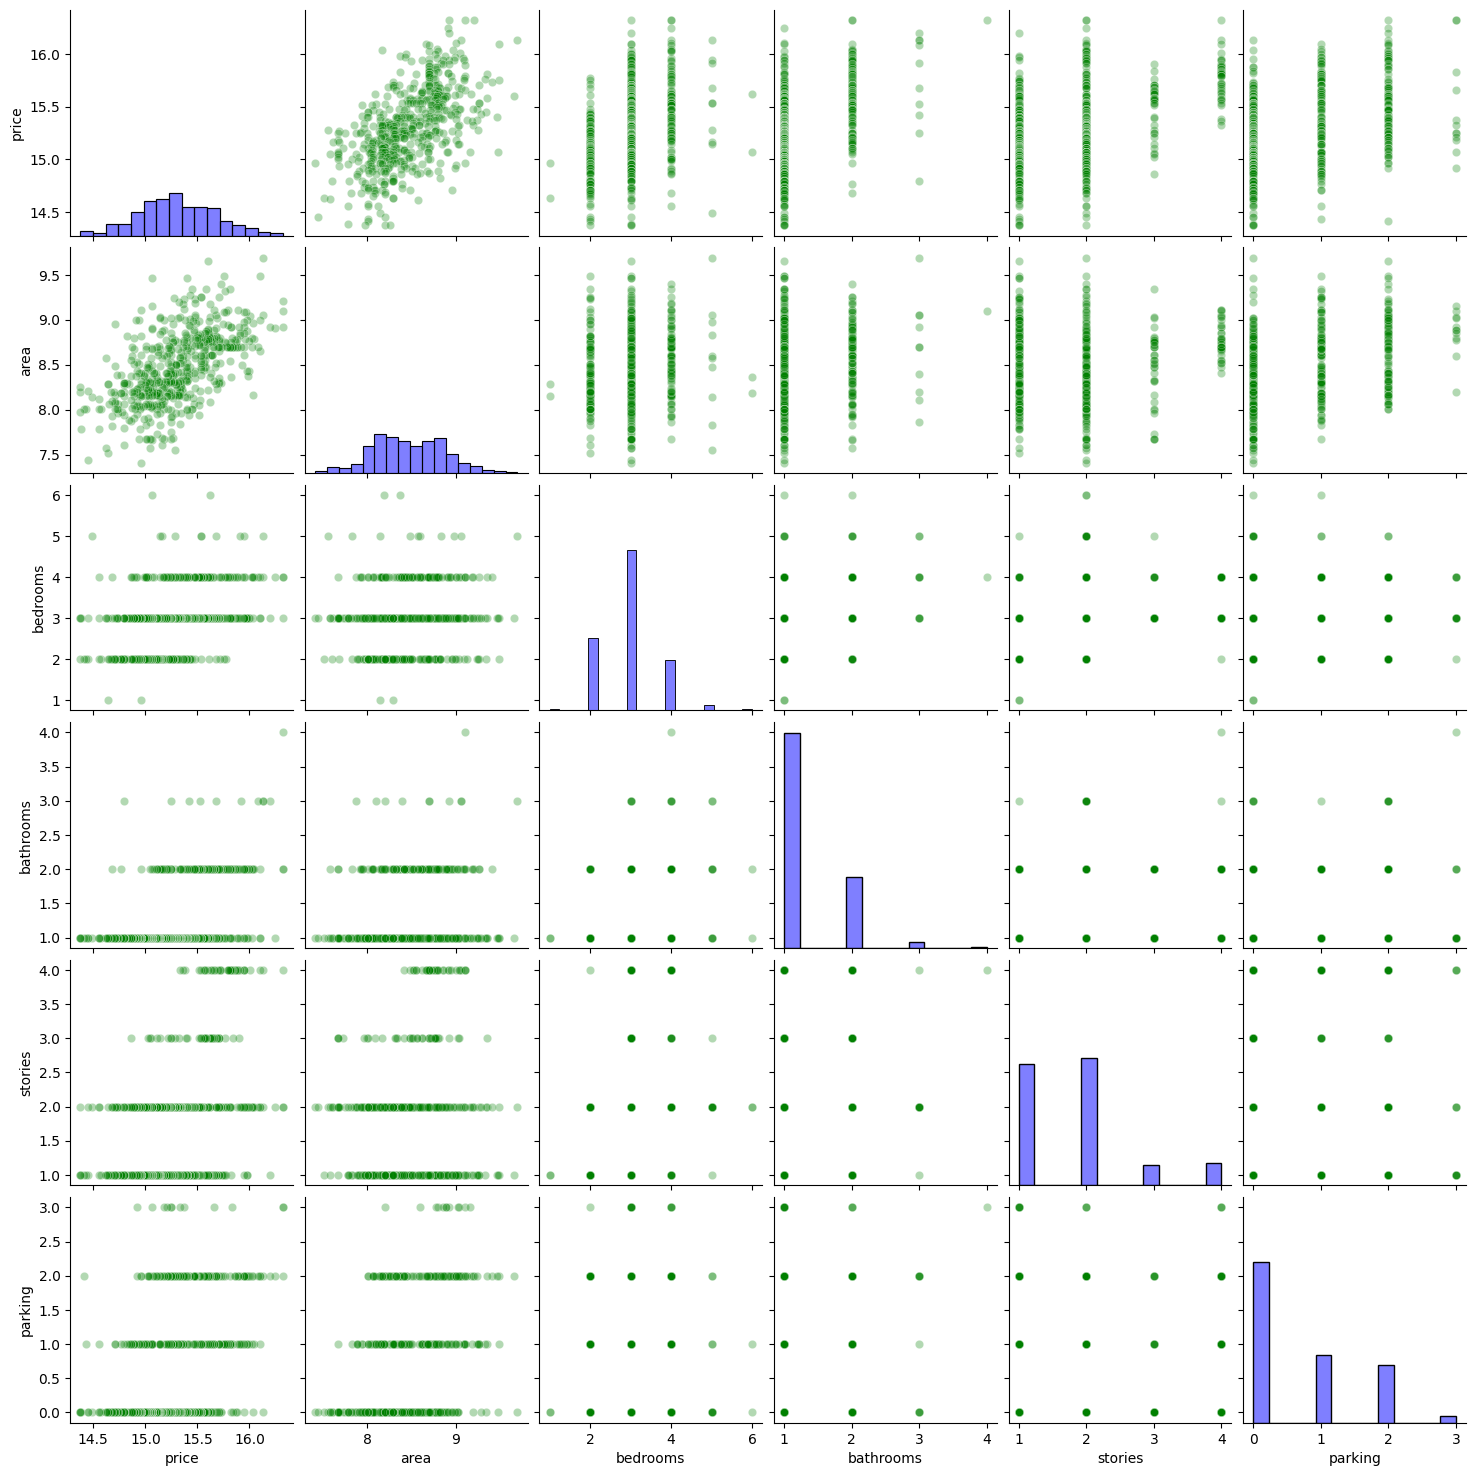

In [58]:
sns.pairplot(house_df, plot_kws={'color': 'green', 'alpha': 0.3}, diag_kws={'color': 'blue', 'alpha': 0.5})
plt.show()

`price` and `area` show a visible **positive linear relationship**, though with substantial variance.

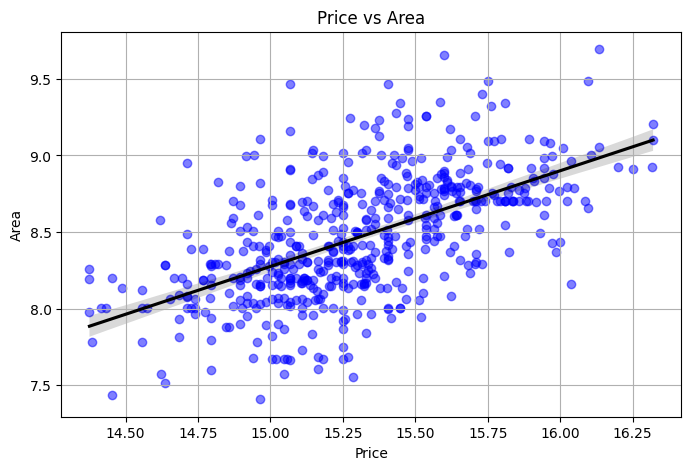

In [59]:
# Scatterplot: Price vs Area

plt.figure(figsize=(8, 5))
sns.regplot(
    x=house_df["price"],
    y=house_df["area"],
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Price vs Area")
plt.xlabel("Price")
plt.ylabel("Area")
plt.grid(True)
plt.show()

> Based on this, `Area` is selected for univariate regression.

##### Univariate Linear Regression

In [60]:
#Splitting of data

X_uni = house_df[['area']].values
y = house_df[['price']].values

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_uni, y, test_size=0.2, random_state=42)

In [62]:
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")

Training set shape: X=(435, 1), y=(435, 1)
Testing set shape: X=(109, 1), y=(109, 1)


In [63]:
#Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
baseline_model = LinearRegression()

In [65]:
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [66]:
y_pred = baseline_model.predict(X_test_scaled)

In [67]:
#Baseline model evaluation

baseline_mae = mean_absolute_error(y_test, y_pred)
baseline_mse = mean_squared_error(y_test, y_pred)
baseline_r2 = r2_score(y_test, y_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline MSE: {baseline_mse:.2f}")
print(f"Baseline R² Score: {baseline_r2:.4f}")

Baseline MAE: 0.26
Baseline MSE: 0.10
Baseline R² Score: 0.4229


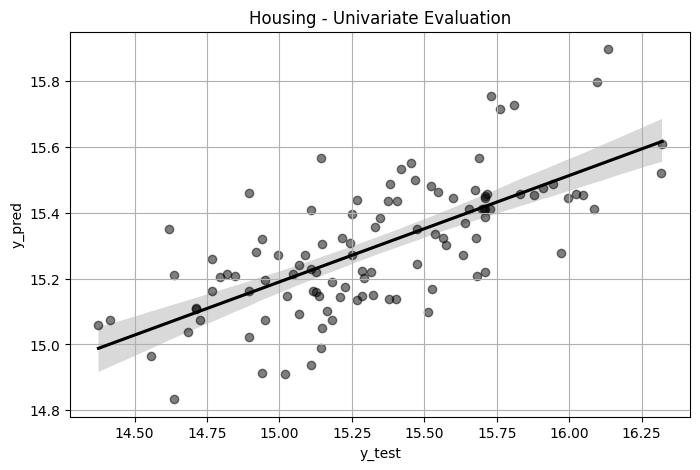

In [68]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'color': 'black', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Housing - Univariate Evaluation")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.show()

These results provide a benchmark for evaluating our custom gradient descent implementation next.

In [69]:
# Adding bias (intercept) term

X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [70]:
# Reshaping y into column vector

y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

In [71]:
# Initialize theta with zeros
theta_init = np.zeros((X_train_bias.shape[1], 1))

In [72]:
# Running gradient descent

learning_rate = 0.01
iterations = 1000

theta_final, cost_history = gradient_descent(X_train_bias, y_train_col, theta_init, learning_rate, iterations)

Iteration 0, Cost: 117.07546659479571
Iteration 100, Cost: 15.723903973402136
Iteration 200, Cost: 2.1448545670414485
Iteration 300, Cost: 0.3255379426970313
Iteration 400, Cost: 0.08178649290368338
Iteration 500, Cost: 0.049128752914213744
Iteration 600, Cost: 0.04475327952882838
Iteration 700, Cost: 0.044167055027304954
Converged at iteration 731, Cost: 0.04412499770144858


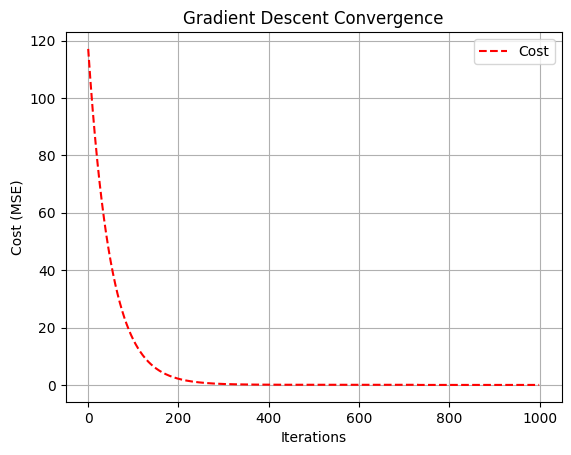

In [73]:
# Gradient Descent convergence

plt.plot(range(len(cost_history)), cost_history, color='red', linestyle='dashed', label='Cost')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
# Predictions on test set
y_pred_gd = X_test_bias @ theta_final

In [75]:
# Gradient descent evaluattion
mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Gradient Descent MAE: {mae_gd:.2f}")
print(f"Gradient Descent MSE: {mse_gd:.2f}")
print(f"Gradient Descent R² Score: {r2_gd:.4f}")

Gradient Descent MAE: 0.26
Gradient Descent MSE: 0.10
Gradient Descent R² Score: 0.4184


This confirms that while `area` has a positive relationship with `price`, it cannot sufficiently explain house prices on its own. Other features like number of bedrooms, location factors, and amenities are likely significant contributors.

##### Multivariate Linear Regression

In [76]:
# Copy for modeling
df = house_df.copy()

In [77]:
# Binary label encoding
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
               'airconditioning', 'prefarea']
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})

# One-hot encoding for furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

C:\Users\eshit\AppData\Local\Temp\ipykernel_19608\3249895279.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


In [78]:
# Features and target

X = df.drop(columns='price').values
y = df[['price']].values

In [79]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
# Baseline Model

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [82]:
#Predict
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [83]:
# Converting back from log scale
y_pred_baseline_original = np.expm1(y_pred_baseline)
y_test_original = np.expm1(y_test)

In [84]:
# Evaluation
baseline_mae = mean_absolute_error(y_test_original, y_pred_baseline_original)
baseline_mse = mean_squared_error(y_test_original, y_pred_baseline_original)
baseline_r2 = r2_score(y_test_original, y_pred_baseline_original)

print(f"Sklearn MAE: {baseline_mae:.2f}")
print(f"Sklearn MSE: {baseline_mse:.2f}")
print(f"Sklearn R² Score: {baseline_r2:.2f}")

Sklearn MAE: 784574.86
Sklearn MSE: 1066262479687.19
Sklearn R² Score: 0.77


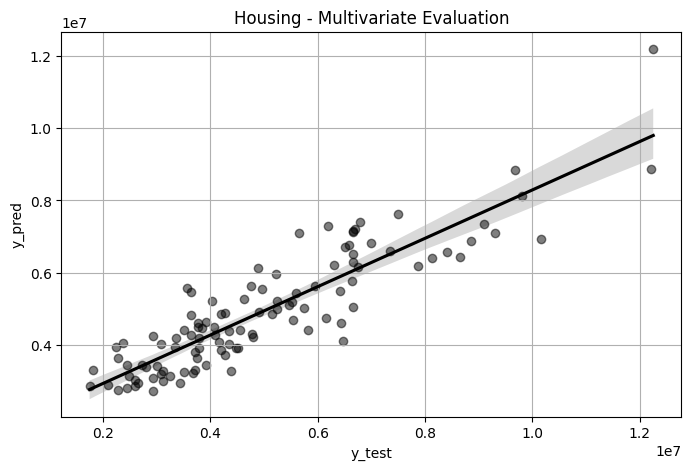

In [86]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=y_test_original,
    y=y_pred_baseline_original,
    scatter_kws={'color': 'black', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Housing - Multivariate Evaluation")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.show()

This model serves as a benchmark to compare against our custom gradient descent implementation.

Applying **Gradient Descent**:

In [87]:
# Adding bias term
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [88]:
# Reshaping target
y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

In [89]:
theta_init = np.zeros((X_train_bias.shape[1], 1))

In [90]:
learning_rate = 0.01
iterations = 1000

theta_final, cost_history = gradient_descent(X_train_bias, y_train_col, theta_init, learning_rate, iterations)

Iteration 0, Cost: 117.07546659479571
Iteration 100, Cost: 15.697723530399415
Iteration 200, Cost: 2.120200836048765
Iteration 300, Cost: 0.301060363748688
Iteration 400, Cost: 0.05730727762902082
Iteration 500, Cost: 0.02463879498609587
Iteration 600, Cost: 0.02025733777881924
Iteration 700, Cost: 0.019668281492035616
Converged at iteration 732, Cost: 0.019624724046193292


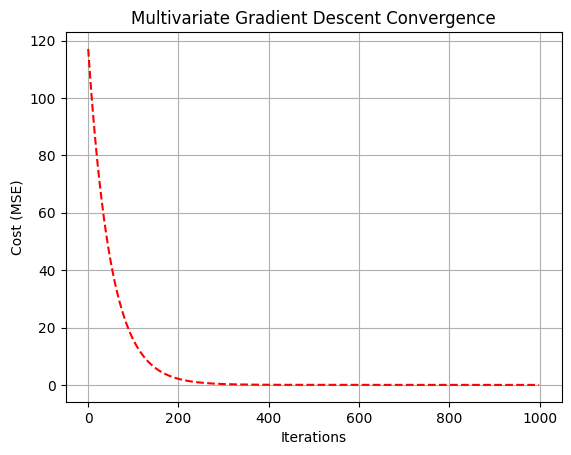

In [91]:
# Cost convergence plot

plt.plot(range(len(cost_history)), cost_history, linestyle='dashed', color='red')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Multivariate Gradient Descent Convergence")
plt.grid(True)
plt.show()

In [92]:
y_pred_gd = X_test_bias @ theta_final

In [93]:
# reverse transformation before evaluation

y_pred_original = np.expm1(y_pred_gd)
y_test_original = np.expm1(y_test_col)

In [94]:
mae_gd = mean_absolute_error(y_test_original, y_pred_original)
mse_gd = mean_squared_error(y_test_original, y_pred_original)
r2_gd = r2_score(y_test_original, y_pred_original)

print(f"GD MAE: {mae_gd:.2f}")
print(f"GD MSE: {mse_gd:.2f}")
print(f"GD R² Score: {r2_gd:.2f}")

GD MAE: 786156.12
GD MSE: 1084441226544.97
GD R² Score: 0.77


The results closely match the Scikit-learn model, validating our gradient descent implementation for multivariate linear regression. 

#### Fuel Consumption (2000 - 2022) Dataset

##### Exploratory Data Analysis (EDA)

In [95]:
fuel_df.head()

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198


In [96]:
print(f"The dataset has {fuel_df.shape[0]} rows and {fuel_df.shape[1]} columns")

The dataset has 22556 rows and 13 columns


In [97]:
#Dataset info and data types
fuel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


In [98]:
fuel_df.describe()

,YEAR,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
count,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000
mean,2011.554442,3.356646,5.854141,12.763513,8.919126,11.034341,27.374534,250.068452
std,6.298269,1.335425,1.819597,3.500999,2.274764,2.910920,7.376982,59.355276
min,2000.000000,0.800000,2.000000,3.500000,3.200000,3.600000,11.000000,83.000000
25%,2006.000000,2.300000,4.000000,10.400000,7.300000,9.100000,22.000000,209.000000
50%,2012.000000,3.000000,6.000000,12.300000,8.400000,10.600000,27.000000,243.000000
75%,2017.000000,4.200000,8.000000,14.725000,10.200000,12.700000,31.000000,288.000000
max,2022.000000,8.400000,16.000000,30.600000,20.900000,26.100000,78.000000,608.000000


In [99]:
fuel_df.isnull().sum()

YEAR                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
HWY (L/100 km)      0
COMB (L/100 km)     0
COMB (mpg)          0
EMISSIONS           0
dtype: int64

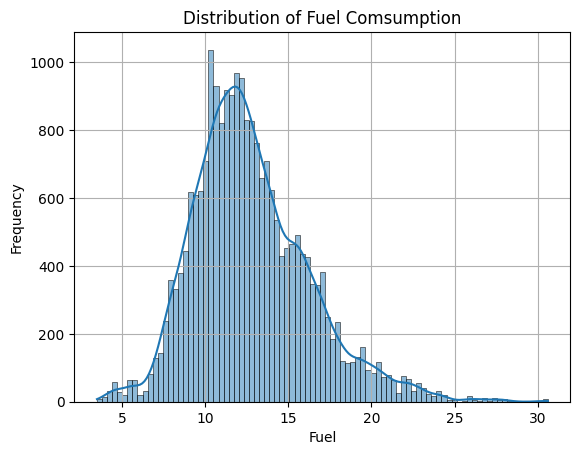

In [100]:
# Distribution of target variable

sns.histplot(fuel_df['FUEL CONSUMPTION'], kde=True)
plt.title("Distribution of Fuel Comsumption")
plt.xlabel("Fuel")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Slight right skewed distribution is observed

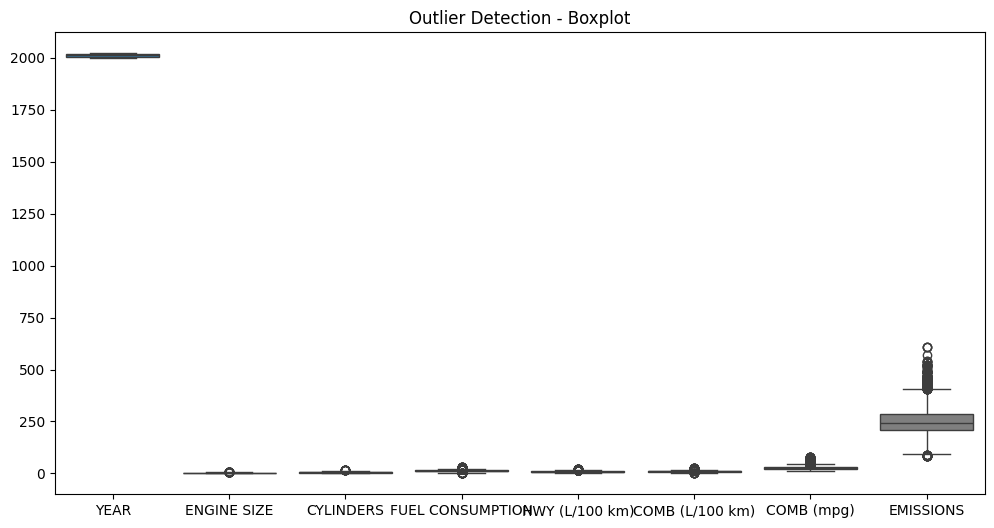

In [101]:
# Outlier detection
plt.figure(figsize=(12,6))
sns.boxplot(data=fuel_df)
plt.title("Outlier Detection - Boxplot")
plt.show()

In [102]:
for col in fuel_df.select_dtypes(include='object').columns:
    print(f"\n{fuel_df[col].value_counts()}\n")


MAKE
CHEVROLET        1725
BMW              1490
GMC              1357
FORD             1276
MERCEDES-BENZ     935
                 ... 
ALFA ROMEO          8
SRT                 4
GENESIS             4
BUGATTI             3
PLYMOUTH            2
Name: count, Length: 87, dtype: int64


MODEL
JETTA                        89
MUSTANG                      88
RANGER                       61
SENTRA                       58
TACOMA                       57
                             ..
Levante Modena V8             1
Levante Modena                1
Levante GT                    1
Ghibli Modena AWD             1
Tundra Hybrid 4WD TRD PRO     1
Name: count, Length: 4242, dtype: int64


VEHICLE CLASS
SUV                         2640
COMPACT                     2636
MID-SIZE                    2300
PICKUP TRUCK - STANDARD     1689
SUBCOMPACT                  1559
FULL-SIZE                   1086
TWO-SEATER                   999
SUV: Small                   929
SUV - SMALL                  827
M

In [103]:
encoded_df = fuel_df.copy()

numeric_df = encoded_df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

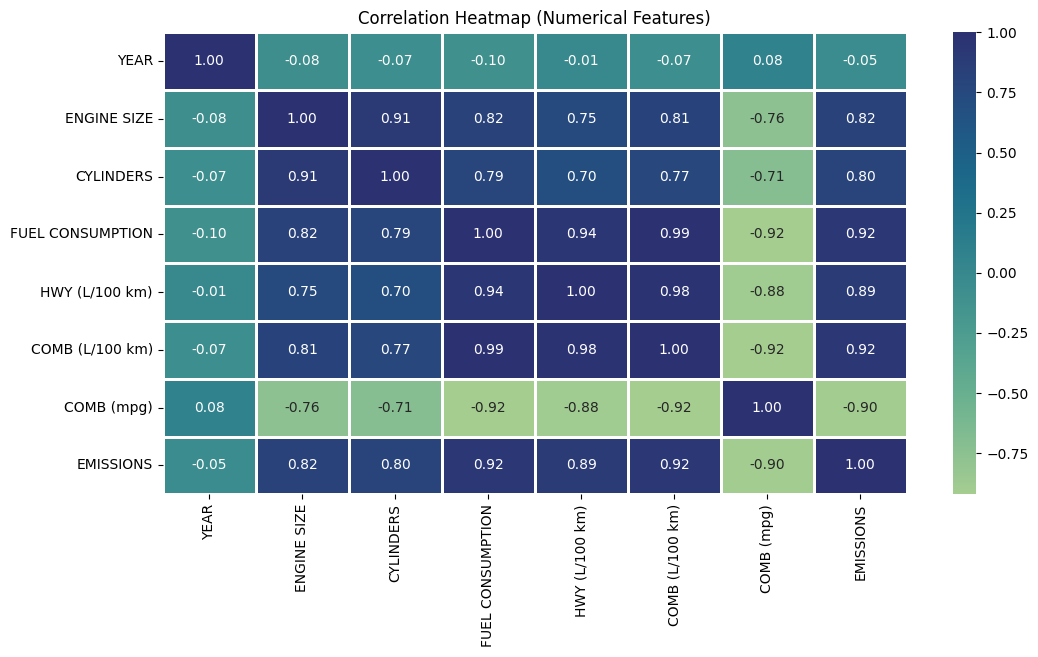

In [104]:
# Feature Correlation Heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='crest', fmt='.2f', linewidths=2)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

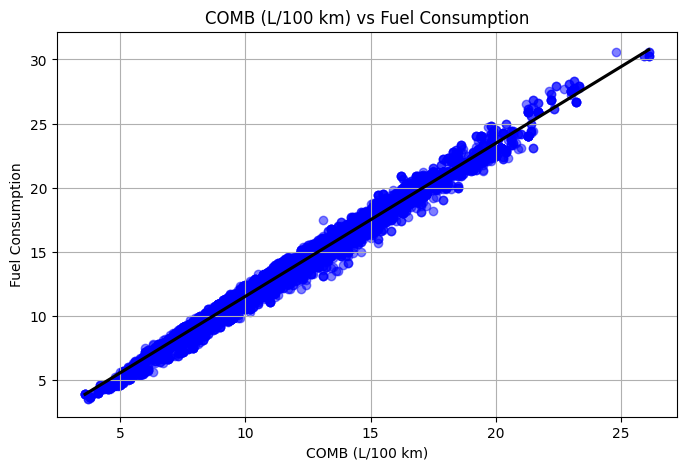

In [105]:
# Scatterplot: COMB (L/100 km) vs Fuel Consumption

plt.figure(figsize=(8, 5))
sns.regplot(
    x=fuel_df["COMB (L/100 km)"],
    y=fuel_df["FUEL CONSUMPTION"],
    scatter_kws={'color': 'blue', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("COMB (L/100 km) vs Fuel Consumption")
plt.xlabel("COMB (L/100 km)")
plt.ylabel("Fuel Consumption")
plt.grid(True)
plt.show()

> Based on this, `COMB (L/100 km)` is selected for univariate regression.

##### Univariate Linear Regression

In [106]:
#Splitting of data

X_uni = fuel_df[['COMB (L/100 km)']].values
y = fuel_df[['FUEL CONSUMPTION']].values

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X_uni, y, test_size=0.2, random_state=42)

In [108]:
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")

Training set shape: X=(18044, 1), y=(18044, 1)
Testing set shape: X=(4512, 1), y=(4512, 1)


In [109]:
#Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
baseline_model = LinearRegression()

In [111]:
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [112]:
y_pred = baseline_model.predict(X_test_scaled)

In [113]:
#Baseline model evaluation

baseline_mae = mean_absolute_error(y_test, y_pred)
baseline_mse = mean_squared_error(y_test, y_pred)
baseline_r2 = r2_score(y_test, y_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline MSE: {baseline_mse:.2f}")
print(f"Baseline R² Score: {baseline_r2:.4f}")

Baseline MAE: 0.32
Baseline MSE: 0.17
Baseline R² Score: 0.9857


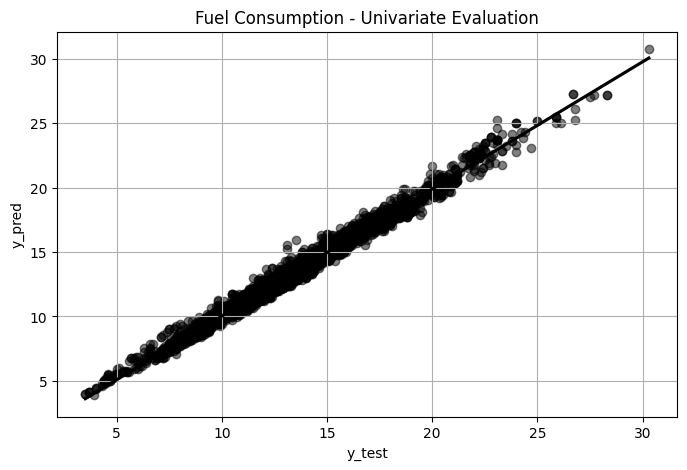

In [114]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'color': 'black', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Fuel Consumption - Univariate Evaluation")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.show()

These results provide a benchmark for evaluating our custom gradient descent implementation next.

In [115]:
# Adding bias (intercept) term

X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [116]:
# Reshaping y into column vector

y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

In [117]:
# Initialize theta with zeros
theta_init = np.zeros((X_train_bias.shape[1], 1))

In [118]:
# Running gradient descent

learning_rate = 0.01
iterations = 1000

theta_final, cost_history = gradient_descent(X_train_bias, y_train_col, theta_init, learning_rate, iterations)

Iteration 0, Cost: 87.41183412768788
Iteration 100, Cost: 11.78581816328666
Iteration 200, Cost: 1.653469133573134
Iteration 300, Cost: 0.29594030502473917
Iteration 400, Cost: 0.11405903396551635
Iteration 500, Cost: 0.08969064040625009
Iteration 600, Cost: 0.0864257709603685
Iteration 700, Cost: 0.0859883448135557
Converged at iteration 716, Cost: 0.08596973340165077


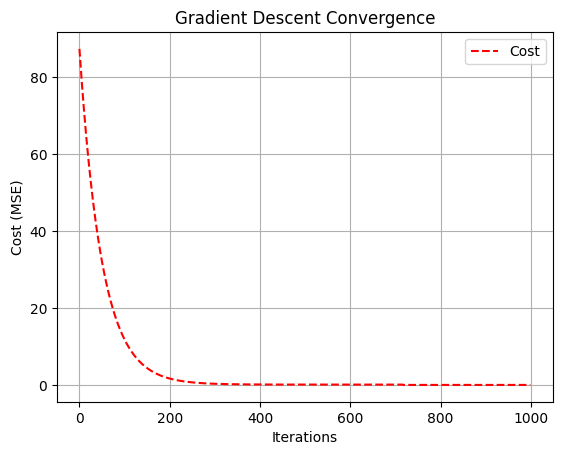

In [119]:
# Gradient Descent convergence

plt.plot(range(len(cost_history)), cost_history, color='red', linestyle='dashed', label='Cost')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

In [120]:
# Predictions on test set
y_pred_gd = X_test_bias @ theta_final

In [121]:
# Gradient descent evaluattion
mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Gradient Descent MAE: {mae_gd:.2f}")
print(f"Gradient Descent MSE: {mse_gd:.2f}")
print(f"Gradient Descent R² Score: {r2_gd:.4f}")

Gradient Descent MAE: 0.32
Gradient Descent MSE: 0.17
Gradient Descent R² Score: 0.9857


The high R² score also validates the correctness of our gradient descent implementation.

##### Multivariate Linear Regression

In [122]:
# Dselected features and target
features = [
    'ENGINE SIZE',
    'CYLINDERS',
    'HWY (L/100 km)',
    'COMB (L/100 km)',
    'EMISSIONS'
]
target = 'FUEL CONSUMPTION'

In [123]:
# Create X and y
X = fuel_df[features].values
y = fuel_df[target].values

In [124]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
# Baseline Model

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [127]:
#Predict
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [128]:
# Evaluation
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Sklearn MAE: {baseline_mae:.2f}")
print(f"Sklearn MSE: {baseline_mse:.2f}")
print(f"Sklearn R² Score: {baseline_r2:.4f}")

Sklearn MAE: 0.06
Sklearn MSE: 0.01
Sklearn R² Score: 0.9995


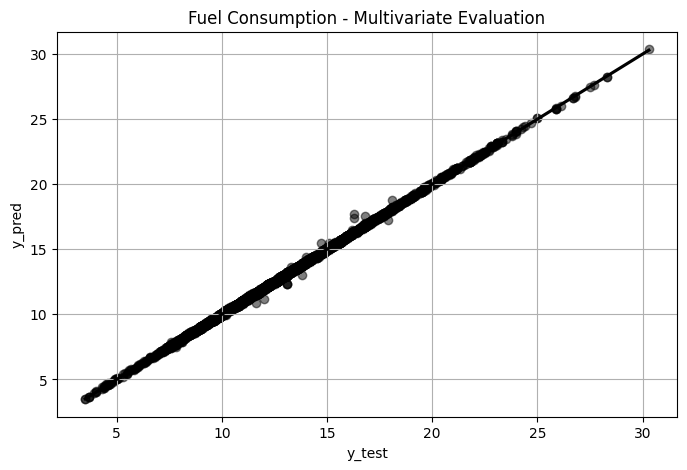

In [130]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=y_test,
    y=y_pred_baseline,
    scatter_kws={'color': 'black', 'alpha': 0.5},
    line_kws={'color': 'black'}
)
plt.title("Fuel Consumption - Multivariate Evaluation")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.show()

This model serves as a benchmark to compare against our custom gradient descent implementation.

Applying **Gradient Descent**:

In [125]:
# Adding bias term
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [126]:
# Reshaping target
y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

In [127]:
theta_init = np.zeros((X_train_bias.shape[1], 1))

In [128]:
learning_rate = 0.005
iterations = 10000

theta_final, cost_history = gradient_descent(X_train_bias, y_train_col, theta_init, learning_rate, iterations)

Iteration 0, Cost: 87.41183412768788
Iteration 100, Cost: 30.28876351757415
Iteration 200, Cost: 11.291175893311895
Iteration 300, Cost: 4.328262347180058
Iteration 400, Cost: 1.7618885267007258
Iteration 500, Cost: 0.8114794545497996
Iteration 600, Cost: 0.4559650109375302
Iteration 700, Cost: 0.32001196244540975
Iteration 800, Cost: 0.26547357148494755
Iteration 900, Cost: 0.24138854749078315
Iteration 1000, Cost: 0.22888357120681127
Iteration 1100, Cost: 0.2209207430482966
Iteration 1200, Cost: 0.2148439924256843
Iteration 1300, Cost: 0.20963003752510548
Iteration 1400, Cost: 0.20487073668450084
Iteration 1500, Cost: 0.20039398923696244
Iteration 1600, Cost: 0.19612099949687462
Iteration 1700, Cost: 0.1920115792014543
Iteration 1800, Cost: 0.1880425880784586
Iteration 1900, Cost: 0.18419906578811227
Iteration 2000, Cost: 0.1804703603876908
Iteration 2100, Cost: 0.17684830730905893
Iteration 2200, Cost: 0.17332629973819216
Iteration 2300, Cost: 0.16989877523552924
Iteration 2400, Cos

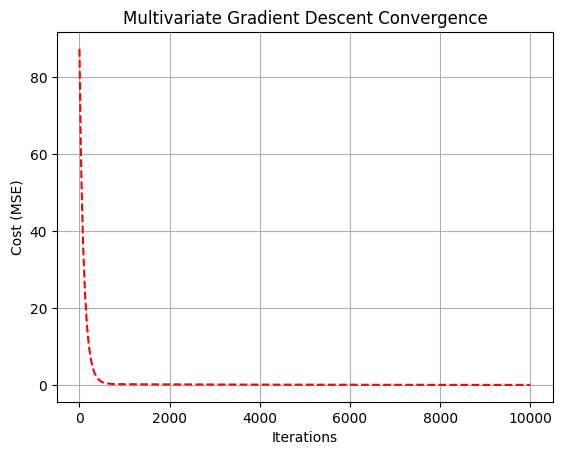

In [129]:
# Cost convergence plot

plt.plot(range(len(cost_history)), cost_history, linestyle='dashed', color='red')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Multivariate Gradient Descent Convergence")
plt.grid(True)
plt.show()

In [130]:
y_pred_gd = X_test_bias @ theta_final

In [131]:
mae_gd = mean_absolute_error(y_test_col, y_pred_gd)
mse_gd = mean_squared_error(y_test_col, y_pred_gd)
r2_gd = r2_score(y_test_col, y_pred_gd)

print(f"GD MAE: {mae_gd:.2f}")
print(f"GD MSE: {mse_gd:.2f}")
print(f"GD R² Score: {r2_gd:.4f}")

GD MAE: 0.21
GD MSE: 0.08
GD R² Score: 0.9933
